In [45]:
# Prompt Chaining Architecture -> 작업을 고정된 하위 작업으로 깔끔하게 분해할 수 있을 때 이상적
# 프로세스의 결과가 다음 프로세스에서 처리(사용)된다

# Routing Architecture -> 입력을 명확하게 분류 할 수 있을때 좋음. 명확하게 분류할 수 없는 입력일 때는 쓰지 않는게...
# 분류기(라우터)는 저렴한 모델로 각각의 프롬프트는 비교적 비싼 모델로 처리함으로써 비용 절약 가능

from typing import Literal

from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command
from pydantic import BaseModel
from typing_extensions import TypedDict

llm = init_chat_model("openai:gpt-4o-mini")

dumb_llm = init_chat_model("openai:gpt-3.5-turbo")
average_llm = init_chat_model("openai:gpt-4o-mini")
smart_llm = init_chat_model("openai:gpt-4o")

In [46]:
class State(TypedDict):

    question: str
    difficulty: str
    answer: str
    model_used: str


class DifficultyResponse(BaseModel):
    difficulty_level: Literal["easy", "medium", "hard"]

In [47]:
def dumb_node(state: State):
    response = dumb_llm.invoke(state["question"])
    return {
        "answer": response.content,
        "model_used": "gpt-3.5",
    }


def average_node(state: State):
    response = average_llm.invoke(state["question"])
    return {
        "answer": response.content,
        "model_used": "gpt-4o-mini",
    }


def smart_node(state: State):
    response = smart_llm.invoke(state["question"])
    return {
        "answer": response.content,
        "model_used": "gpt-4o",
    }


def assess_difficulty(state: State):
    structured_llm = llm.with_structured_output(DifficultyResponse)

    response = structured_llm.invoke(
        f"""
        Assess the difficulty of this question
        Question: {state["question"]}

        - EASY: Simple facts, basic definitions, yes/no answers
        - MEDIUM: Requires explanation, comparison, analysis
        - HARD: Complex reasoning, multiple steps, deep expertise.
        """
    )

    difficulty_level = response.difficulty_level

    if difficulty_level == "easy":
        goto = "dumb_node"
    elif difficulty_level == "medium":
        goto = "average_node"
    elif difficulty_level == "hard":
        goto = "smart_node"

    return Command(
        goto=goto,
        update={"difficulty": difficulty_level},
    )

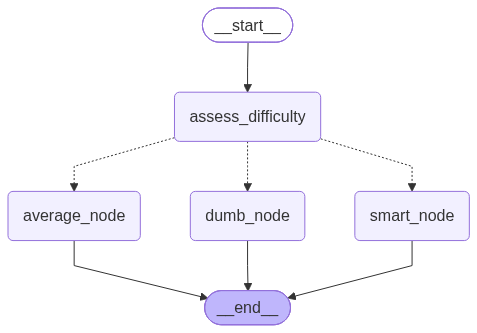

In [48]:
graph_builder = StateGraph(State)

graph_builder.add_node("dumb_node", dumb_node)
graph_builder.add_node("average_node", average_node)
graph_builder.add_node("smart_node", smart_node)
graph_builder.add_node(
    "assess_difficulty",
    assess_difficulty,
    destinations=("dumb_node", "average_node", "smart_node"),
)

graph_builder.add_edge(START, "assess_difficulty")

graph_builder.add_edge("dumb_node", END)
graph_builder.add_edge("average_node", END)
graph_builder.add_edge("smart_node", END)

graph = graph_builder.compile()
graph

In [49]:
graph.invoke({"question": "AI 관련해서 Agent와 Workflow의 차이점을 설명해봐"})

/Users/93minki/Desktop/Study/nomadcoder-ai-master-class-study/workflow-architectures/.venv/lib/python3.13/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DifficultyResponse(difficulty_level='medium'), input_type=DifficultyResponse])
  return self.__pydantic_serializer__.to_python(


{'question': 'AI 관련해서 Agent와 Workflow의 차이점을 설명해봐',
 'difficulty': 'medium',
 'answer': 'AI와 관련된 "Agent"와 "Workflow"는 서로 다른 개념으로, 각각의 역할과 기능이 다릅니다. 다음은 두 개념의 차이를 설명합니다.\n\n### Agent\n- **정의**: Agent는 특정 작업을 수행하기 위해 자율적으로 또는 반자율적으로 행동하는 시스템이나 프로그램입니다. AI 에이전트는 주어진 환경에서 데이터를 수집하고, 분석하며, 결정을 내리고, 필요에 따라 행동을 취합니다.\n- **특징**:\n  - **자율성**: 에이전트는 스스로 결정을 내릴 수 있는 능력을 갖추고 있습니다.\n  - **상황 인식**: 환경을 인식하고, 변화에 적응할 수 있는 능력을 지니고 있습니다.\n  - **정보 처리**: 데이터 수집, 학습, 판단 및 행동을 통해 문제를 해결합니다.\n- **예시**: 자율주행차, 챗봇, 추천 시스템 등.\n\n### Workflow\n- **정의**: Workflow는 일련의 작업이나 프로세스가 순차적으로 또는 병렬로 진행되는 구조를 의미합니다. AI 관련 Workflow는 주로 데이터 수집, 처리, 분석 및 결과 생성과 같은 과정을 포함합니다.\n- **특징**:\n  - **프로세스 지향**: 여러 단계를 포함하며, 각 단계는 특정 작업이나 역할을 수행합니다.\n  - **협업**: 다양한 시스템, 사람 및 도구가 함께 작업하여 결과를 생성합니다.\n  - **자동화**: 종종 자동화된 시스템을 통해 반복적인 작업을 수행하여 효율성을 높입니다.\n- **예시**: 데이터 수집, 전처리, 모델 훈련, 결과 평가, 배포 등의 복합 절차.\n\n### 차이점 요약\n- **에이전트**는 독립적으로 작업을 수행하는 주체인 반면, **워크플로우**는 여러 작업이 어떻게 구성되고 진행되는지를 남는 구조입니다.\n- 에이전트는 주로 실시간 결정 및 행동과 관련이 있는 반면, 워